# IMPORT LIBRARIES

In [1]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# IMPORT DATA

In [2]:
import json
import os

# Base folder
results_dir = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results"

# File paths
economic_file = os.path.join(results_dir, "economic_baseline_seed10.json")
sustain_file = os.path.join(results_dir, "sustainability_aware_seed10.json")

# -----------------------------
# Load results
# -----------------------------
with open(economic_file, "r") as f:
    econ = json.load(f)

with open(sustain_file, "r") as f:
    sust = json.load(f)

# -----------------------------
# Inspect structure
# -----------------------------
print("Economic result keys:")
print(econ.keys())

print("\nSustainability result keys:")
print(sust.keys())

Economic result keys:
dict_keys(['objective_value', 'variables', 'export_meta'])

Sustainability result keys:
dict_keys(['objective_value', 'variables', 'export_meta'])


# ANALYZE

## OBJECTIVE FUNCTIONS

Economic: {'work_days': 134, 'travel_moves': 188, 'hotel_days': 360, 'idle_away_days': 17, 'lateness': 6.0}
Sustainability: {'work_days': 133, 'travel_moves': 89, 'hotel_days': 0, 'idle_away_days': 0, 'lateness': 28.0}


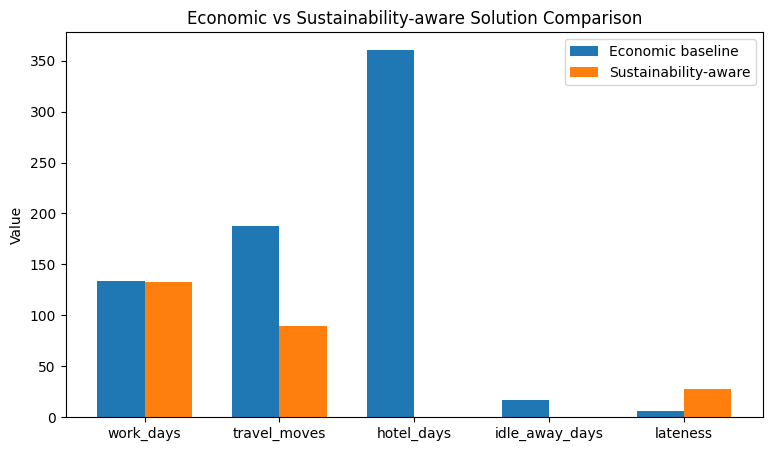

In [3]:
import json
import matplotlib.pyplot as plt

# -------------------------------------------------
# LOAD RESULTS
# -------------------------------------------------
with open("results/economic_baseline_seed10.json") as f:
    econ = json.load(f)

with open("results/sustainability_aware_seed10.json") as f:
    sust = json.load(f)

econ_vars = econ["variables"]
sust_vars = sust["variables"]

# -------------------------------------------------
# EXTRACT METRICS
# -------------------------------------------------
def get_metrics(vars):

    z = vars.get("z", {})
    y = vars.get("y", {})
    hotel = vars.get("hotel", {})
    L = vars.get("L", {})
    idle = vars.get("idle_away", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle),
        "lateness": sum(L.values()) if L else 0
    }

econ_metrics = get_metrics(econ_vars)
sust_metrics = get_metrics(sust_vars)

print("Economic:", econ_metrics)
print("Sustainability:", sust_metrics)

# -------------------------------------------------
# PLOT COMPARISON
# -------------------------------------------------
labels = list(econ_metrics.keys())
econ_vals = [econ_metrics[k] for k in labels]
sust_vals = [sust_metrics[k] for k in labels]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar([i-width/2 for i in x], econ_vals, width, label="Economic baseline")
plt.bar([i+width/2 for i in x], sust_vals, width, label="Sustainability-aware")

plt.xticks(x, labels)
plt.ylabel("Value")
plt.title("Economic vs Sustainability-aware Solution Comparison")
plt.legend()

plt.show()

## TRAVEL MODE

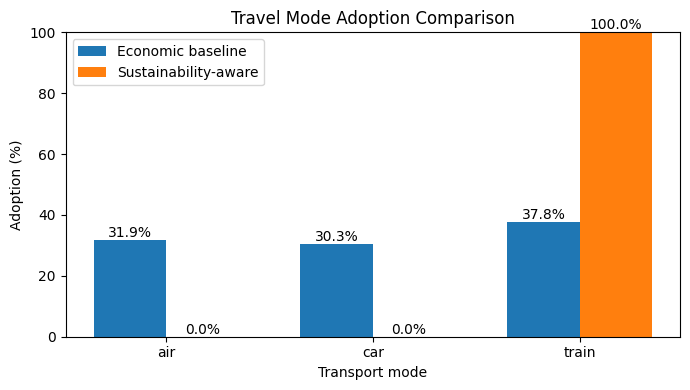

In [4]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# LOAD RESULTS
# -------------------------------------------------
with open("results/economic_baseline_seed10.json") as f:
    econ = json.load(f)

with open("results/sustainability_aware_seed10.json") as f:
    sust = json.load(f)

y_econ = econ["variables"]["y"]
y_sust = sust["variables"]["y"]

# -------------------------------------------------
# FUNCTION TO COUNT TRIPS BY MODE
# -------------------------------------------------
def count_modes(y):

    mode_count = Counter()

    for key, val in y.items():
        if val > 0.5:
            mode = key.split("|")[-1]
            mode_count[mode] += 1

    total = sum(mode_count.values())

    return {m: 100*mode_count[m]/total for m in mode_count}

econ_modes = count_modes(y_econ)
sust_modes = count_modes(y_sust)

# union of all modes
modes = sorted(set(econ_modes) | set(sust_modes))

econ_vals = [econ_modes.get(m,0) for m in modes]
sust_vals = [sust_modes.get(m,0) for m in modes]

# -------------------------------------------------
# PLOT COMPARISON
# -------------------------------------------------
x = np.arange(len(modes))
width = 0.35

plt.figure(figsize=(7,4))

plt.bar(x - width/2, econ_vals, width, label="Economic baseline")
plt.bar(x + width/2, sust_vals, width, label="Sustainability-aware")

plt.xticks(x, modes)
plt.ylabel("Adoption (%)")
plt.xlabel("Transport mode")
plt.title("Travel Mode Adoption Comparison")
plt.ylim(0,100)
plt.legend()

# percentage labels
for i,v in enumerate(econ_vals):
    plt.text(i-width/2, v+1, f"{v:.1f}%", ha='center')

for i,v in enumerate(sust_vals):
    plt.text(i+width/2, v+1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

## TECHNICIAN CHOICHE


Percentage composition by scenario:
category  Both  Only most skilled  Only closest  Neither
scenario                                                
ECO       68.0               12.0          16.0      4.0
SUST      80.0                2.0          18.0      0.0


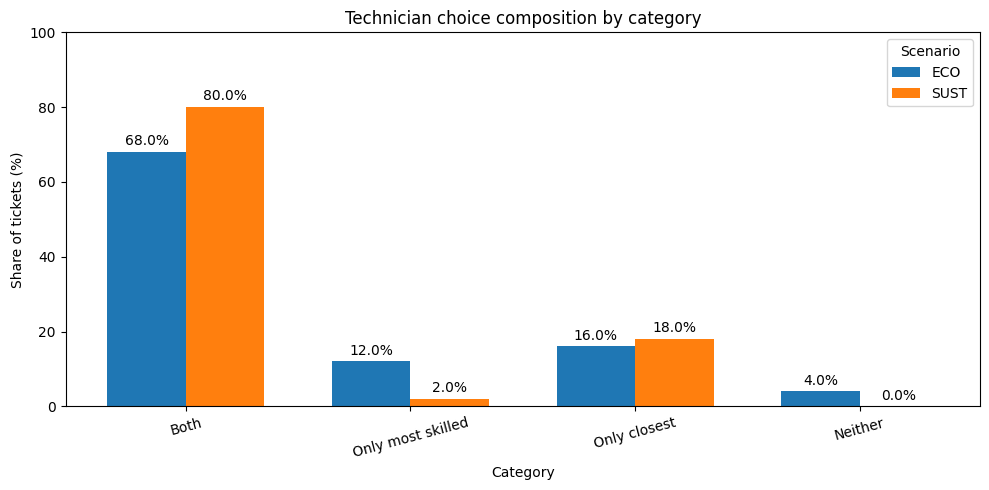

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =================================================
# PATHS
# =================================================
INPUT_PATH = "instances/demo_clustered_seed10.json"
ECO_RESULTS_PATH = "results/economic_baseline_seed10.json"
SUST_RESULTS_PATH = "results/sustainability_aware_seed10.json"

# =================================================
# LOAD JSON
# =================================================
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

# =================================================
# PARSING HELPERS
# =================================================
def parse_start_key(key):
    # expected format: t|k|d
    parts = key.split("|")
    if len(parts) != 3:
        raise ValueError(f"Unexpected start key format: {key}")
    return parts[0], parts[1], parts[2]

def get_nested_or_flat(data_dict, key1, key2, name="value"):
    """
    Supports either:
      - nested dict: data_dict[key1][key2]
      - flat dict:   data_dict['key1|key2']
    """
    if key1 in data_dict and isinstance(data_dict[key1], dict) and key2 in data_dict[key1]:
        return float(data_dict[key1][key2])

    flat_key = f"{key1}|{key2}"
    if flat_key in data_dict:
        return float(data_dict[flat_key])

    raise KeyError(f"Cannot find {name} for ({key1}, {key2})")

def get_chosen_technician(result_variables):
    """
    Reads variables['start'] and returns:
        {ticket: chosen_technician}
    """
    chosen = {}
    start = result_variables.get("start", {})

    for key, value in start.items():
        if float(value) > 0.5:
            ticket, tech, _ = parse_start_key(key)
            chosen[ticket] = tech

    return chosen

# =================================================
# CLASSIFICATION LOGIC
# =================================================
def classify_choice(chosen_tech, best_skill_set, closest_set):
    is_most_skilled = chosen_tech in best_skill_set
    is_closest = chosen_tech in closest_set

    if is_most_skilled and is_closest:
        category = "Both"
    elif is_most_skilled:
        category = "Only most skilled"
    elif is_closest:
        category = "Only closest"
    else:
        category = "Neither"

    return is_most_skilled, is_closest, category

# =================================================
# MAIN DATA PREPARATION
# =================================================
instance = load_json(INPUT_PATH)
econ = load_json(ECO_RESULTS_PATH)
sust = load_json(SUST_RESULTS_PATH)

tickets = list(instance["T"])
technicians = list(instance["K"])

ticket_node_map = instance["node"]
tech_base_map = instance["base"]
dist_data = instance["dist"]
dur_data = instance["dur"]

econ_choice = get_chosen_technician(econ.get("variables", {}))
sust_choice = get_chosen_technician(sust.get("variables", {}))

records = []

for ticket in tickets:
    ticket_node = ticket_node_map[ticket]

    skill_values = []
    distance_values = []

    for tech in technicians:
        dur_val = get_nested_or_flat(dur_data, ticket, tech, name="dur")
        dist_val = get_nested_or_flat(dist_data, tech_base_map[tech], ticket_node, name="dist")

        skill_values.append((tech, dur_val))
        distance_values.append((tech, dist_val))

    best_skill_value = min(value for _, value in skill_values)
    closest_value = min(value for _, value in distance_values)

    best_skill_set = {tech for tech, value in skill_values if abs(value - best_skill_value) <= 1e-9}
    closest_set = {tech for tech, value in distance_values if abs(value - closest_value) <= 1e-9}

    for scenario_name, scenario_choice in [("ECO", econ_choice), ("SUST", sust_choice)]:
        chosen_tech = scenario_choice.get(ticket)

        if chosen_tech is None:
            continue

        is_most_skilled, is_closest, category = classify_choice(
            chosen_tech=chosen_tech,
            best_skill_set=best_skill_set,
            closest_set=closest_set
        )

        records.append({
            "scenario": scenario_name,
            "ticket": ticket,
            "chosen_tech": chosen_tech,
            "is_most_skilled": int(is_most_skilled),
            "is_closest": int(is_closest),
            "category": category
        })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError("No assignments found. Check that results files contain variables['start'].")

# =================================================
# SUMMARY TABLE
# =================================================
category_order = ["Both", "Only most skilled", "Only closest", "Neither"]
scenario_order = ["ECO", "SUST"]

summary_counts = (
    df.groupby(["scenario", "category"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=scenario_order, columns=category_order, fill_value=0)
)

summary_pct = summary_counts.div(summary_counts.sum(axis=1), axis=0) * 100

print("\nPercentage composition by scenario:")
print(summary_pct.round(2))

# =================================================
# RESHAPE FOR GROUPED BAR CHART
# x = category
# hue = scenario
# =================================================
plot_df = (
    summary_pct.reset_index()
    .melt(id_vars="scenario", var_name="category", value_name="percentage")
)

x = np.arange(len(category_order))
bar_width = 0.35

eco_values = [
    plot_df[(plot_df["scenario"] == "ECO") & (plot_df["category"] == cat)]["percentage"].iloc[0]
    for cat in category_order
]

sust_values = [
    plot_df[(plot_df["scenario"] == "SUST") & (plot_df["category"] == cat)]["percentage"].iloc[0]
    for cat in category_order
]

# =================================================
# PLOT
# =================================================
plt.figure(figsize=(10, 5))

bars_eco = plt.bar(x - bar_width / 2, eco_values, bar_width, label="ECO")
bars_sust = plt.bar(x + bar_width / 2, sust_values, bar_width, label="SUST")

plt.xticks(x, category_order, rotation=15)
plt.xlabel("Category")
plt.ylabel("Share of tickets (%)")
plt.title("Technician choice composition by category")
plt.ylim(0, 100)
plt.legend(title="Scenario")

# percentage labels on bars
for bars in [bars_eco, bars_sust]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

## SCHEDULING

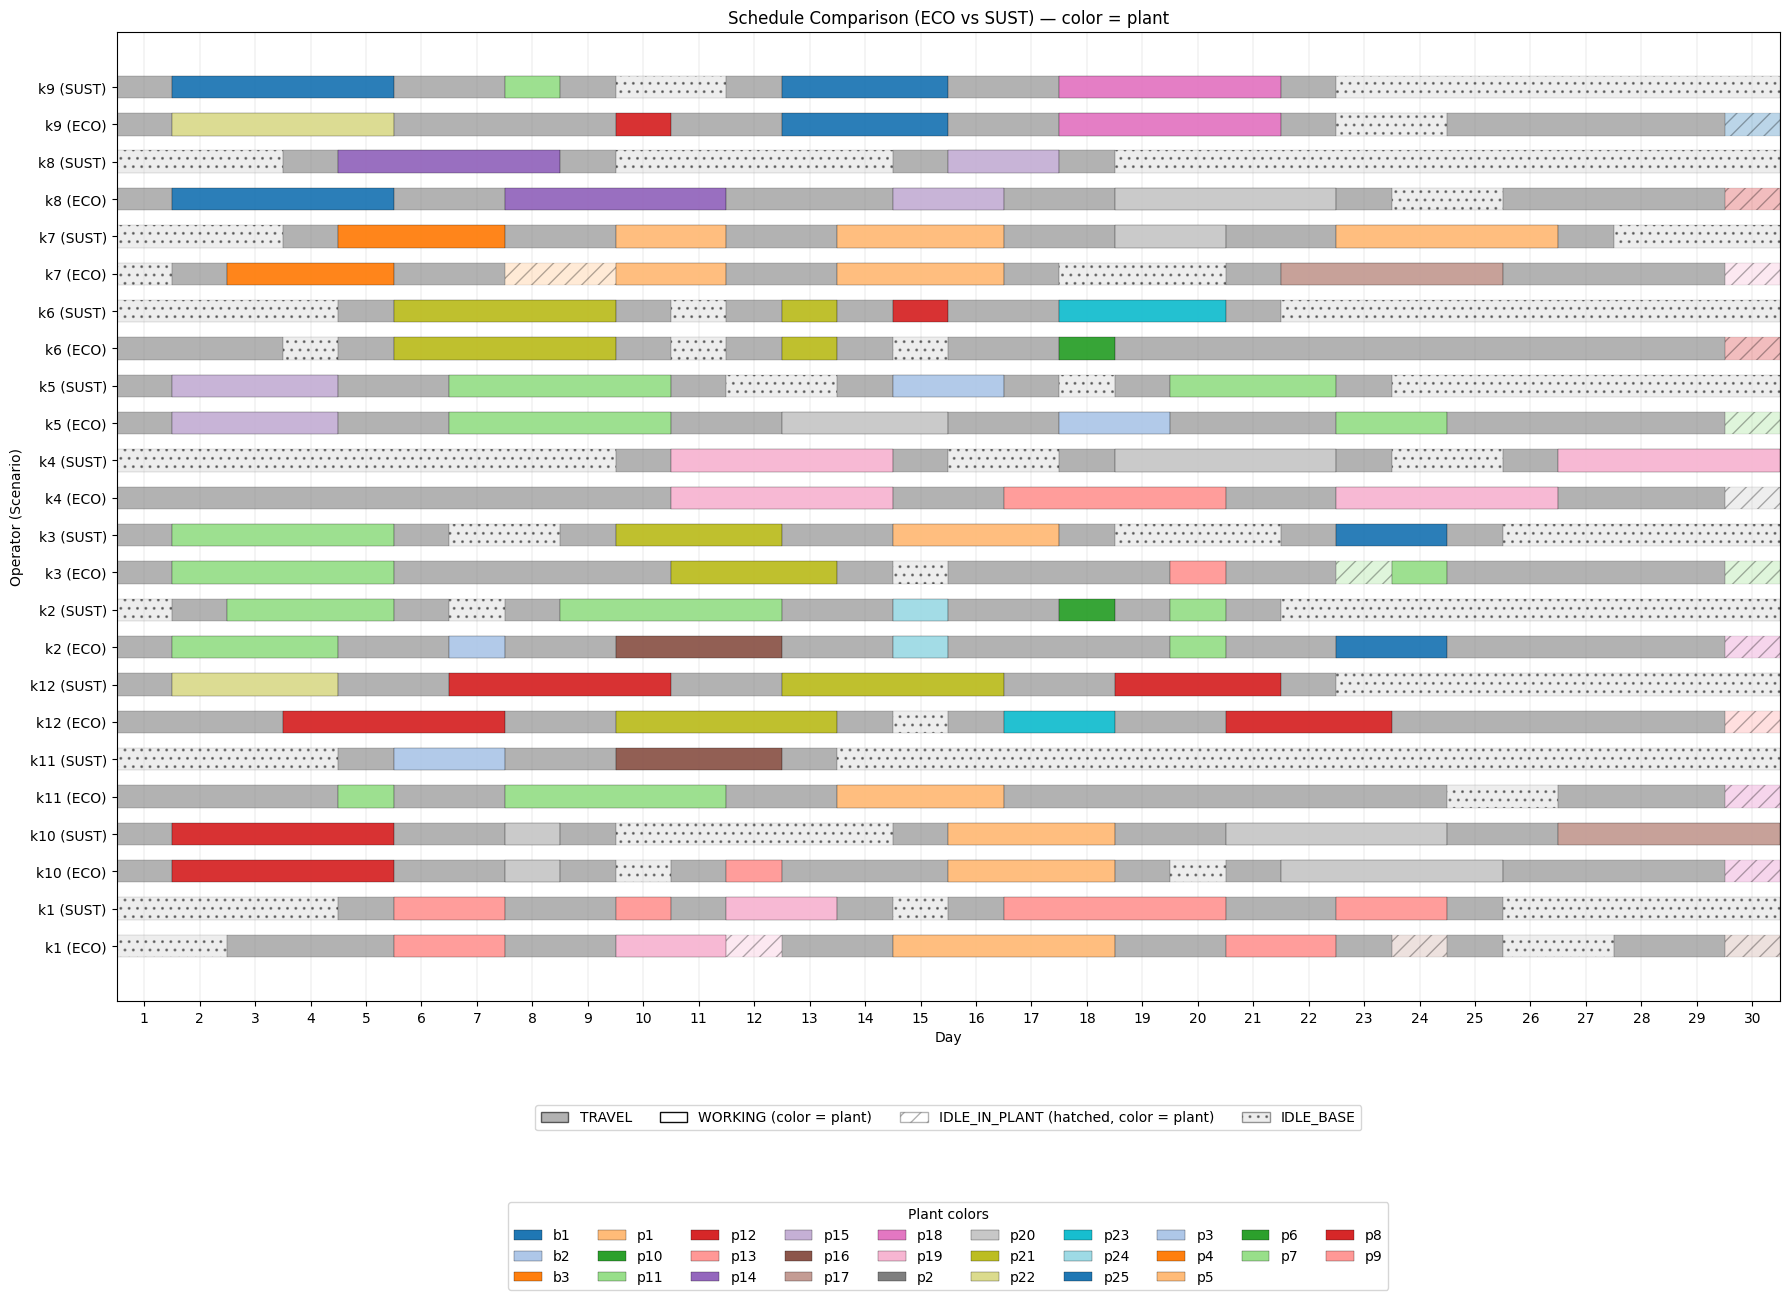

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PATHS
# -----------------------------
ECO_RESULTS_PATH  = "results/economic_baseline_seed10.json"
SUST_RESULTS_PATH = "results/sustainability_aware_seed10.json"

# -----------------------------
# HELPERS
# -----------------------------
def parse_key(key: str):
    return key.split("|")

def load_vars(path):
    with open(path, "r") as f:
        res = json.load(f)
    vars_ = res.get("variables", {})
    return {
        "loc": vars_.get("loc", {}),
        "z": vars_.get("z", {}),
        "y": vars_.get("y", {}),
    }

def build_df_sched(loc, z, y, scenario_label):
    place_by_kd = {}      # (k,d) -> node
    work_set = set()      # (k,d)
    travel_set = set()    # (k,d)
    all_days = set()
    all_ops = set()
    all_places = set()

    # locations
    for key, val in loc.items():
        if float(val) <= 0:
            continue
        n, k, d = parse_key(key)
        d = int(d)
        place_by_kd[(k, d)] = n
        all_days.add(d); all_ops.add(k); all_places.add(n)

    # working
    for key, val in z.items():
        if float(val) <= 0:
            continue
        _, k, d = parse_key(key)
        d = int(d)
        work_set.add((k, d))
        all_days.add(d); all_ops.add(k)

    # travel (departure day)
    for key, val in y.items():
        if float(val) <= 0:
            continue
        i, j, k, d, md = parse_key(key)
        d = int(d)
        travel_set.add((k, d))
        all_days.add(d); all_ops.add(k)

    if not all_days or not all_ops:
        raise ValueError(f"No scheduling data found for scenario={scenario_label}")

    d_min, d_max = min(all_days), max(all_days)
    days = list(range(d_min, d_max + 1))

    rows = []
    for k in sorted(all_ops):
        for d in days:
            n = place_by_kd.get((k, d))
            is_work = (k, d) in work_set
            is_travel = (k, d) in travel_set

            if n is None:
                status = "UNKNOWN"
            elif is_travel:
                status = "TRAVEL"
            elif is_work:
                status = "WORKING"
            else:
                if str(n).lower().startswith("b") or str(n).lower().startswith("base"):
                    status = "IDLE_BASE"
                else:
                    status = "IDLE_IN_PLANT"

            rows.append({
                "operator": k,
                "day": d,
                "plant": n,
                "status": status,
                "scenario": scenario_label,
                "op_label": f"{k} ({scenario_label})"
            })

    df = pd.DataFrame(rows)
    return df, d_min, d_max, sorted(all_places)

def build_segments(df_sched, op_label):
    g = df_sched[df_sched["op_label"] == op_label].sort_values("day")
    if g.empty:
        return []

    segments = []
    cur_status = None
    cur_plant = None
    start_day = None

    def close_segment(end_day):
        if cur_status in ("WORKING", "IDLE_IN_PLANT", "IDLE_BASE", "TRAVEL"):
            segments.append({
                "op_label": op_label,
                "status": cur_status,
                "plant": cur_plant,
                "start": int(start_day),
                "length": int(end_day - start_day + 1),
            })

    for _, r in g.iterrows():
        d = int(r["day"])
        status = r["status"]
        plant = r["plant"]

        if cur_status is None:
            cur_status = status
            cur_plant = plant
            start_day = d
            continue

        same = (
            status == cur_status
            and (status in ("TRAVEL",) or plant == cur_plant)
        )

        if same:
            continue

        close_segment(d - 1)
        cur_status = status
        cur_plant = plant
        start_day = d

    close_segment(int(g["day"].max()))
    return segments

# -----------------------------
# LOAD BOTH RUNS
# -----------------------------
eco = load_vars(ECO_RESULTS_PATH)
sust = load_vars(SUST_RESULTS_PATH)

df_eco, dmin_e, dmax_e, plants_e = build_df_sched(eco["loc"], eco["z"], eco["y"], "ECO")
df_sus, dmin_s, dmax_s, plants_s = build_df_sched(sust["loc"], sust["z"], sust["y"], "SUST")
df_sched = pd.concat([df_eco, df_sus], ignore_index=True)

# global horizon across the two schedules
d_min = min(dmin_e, dmin_s)
d_max = max(dmax_e, dmax_s)
days = list(range(d_min, d_max + 1))

# plants across both runs (consistent colors)
plants = sorted(set(plants_e) | set(plants_s))

# -----------------------------
# SEGMENTS FOR ALL OP_LABELS
# Order: k1 ECO, k1 SUST, k2 ECO, k2 SUST, ...
# -----------------------------
all_ops = sorted(set(df_sched["operator"]))
op_labels = []
for k in all_ops:
    op_labels.append(f"{k} (ECO)")
    op_labels.append(f"{k} (SUST)")

segments = []
for opl in op_labels:
    segments.extend(build_segments(df_sched, opl))
segments_df = pd.DataFrame(segments)

# -----------------------------
# COLORS (plants)
# -----------------------------
cmap = plt.get_cmap("tab20")
plant_to_color = {p: cmap(i % 20) for i, p in enumerate(plants)}

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(18, max(6, len(op_labels) * 0.55)))
op_to_y = {opl: i for i, opl in enumerate(op_labels)}
schedule_h = 0.60

for _, seg in segments_df.iterrows():
    yrow = op_to_y[seg["op_label"]]
    status = seg["status"]
    plant = seg["plant"]

    if status == "TRAVEL":
        facecolor = "grey"
        alpha = 0.6
        hatch = None
    elif status == "WORKING":
        facecolor = plant_to_color.get(plant, "lightgrey")
        alpha = 0.95
        hatch = None
    elif status == "IDLE_IN_PLANT":
        facecolor = plant_to_color.get(plant, "lightgrey")
        alpha = 0.30
        hatch = "//"
    elif status == "IDLE_BASE":
        facecolor = "lightgrey"
        alpha = 0.40
        hatch = ".."
    else:
        facecolor = "white"
        alpha = 0.20
        hatch = "xx"

    ax.barh(
        y=yrow,
        width=seg["length"],
        left=seg["start"] - 0.5,
        height=schedule_h,
        color=facecolor,
        alpha=alpha,
        edgecolor="black",
        linewidth=0.2,
        hatch=hatch,
        zorder=1
    )

# Axes + grid
ax.set_yticks([op_to_y[opl] for opl in op_labels])
ax.set_yticklabels(op_labels)

ax.set_xlim(d_min - 0.5, d_max + 0.5)
ax.set_xticks(days)
ax.set_xlabel("Day")
ax.set_ylabel("Operator (Scenario)")
ax.set_title("Schedule Comparison (ECO vs SUST) — color = plant")

for d in days:
    ax.axvline(d, linewidth=0.3, color="black", alpha=0.2, zorder=0)

# -----------------------------
# LEGENDS:
#   1) STATUS legend (centered below chart)
#   2) PLANT color legend (also below chart, second row)
# -----------------------------
status_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", alpha=0.6),
    plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", alpha=0.95),
    plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", alpha=0.30, hatch="//"),
    plt.Rectangle((0, 0), 1, 1, facecolor="lightgrey", edgecolor="black", alpha=0.40, hatch=".."),
]
status_labels = [
    "TRAVEL",
    "WORKING (color = plant)",
    "IDLE_IN_PLANT (hatched, color = plant)",
    "IDLE_BASE",
]

leg1 = ax.legend(
    status_handles, status_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=4,
    frameon=True
)
ax.add_artist(leg1)  # keep this legend when adding second one

# Plant legend (colors)
plant_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=plant_to_color[p], edgecolor="black", linewidth=0.2)
    for p in plants
]
plant_labels = [str(p) for p in plants]

# Put plant legend below the status legend (second row)
ax.legend(
    plant_handles, plant_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=min(len(plants), 10),
    frameon=True,
    title="Plant colors"
)

plt.tight_layout()
plt.show()

## ROUTING

In [8]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import math

# =========================================================
# CONFIG
# =========================================================
INPUT_PATH = "instances/demo_clustered_seed10.json"          # <-- your instance with _meta.coords
ECO_RESULTS_PATH = "results/economic_baseline_seed10.json"
SUST_RESULTS_PATH = "results/sustainability_aware_seed10.json"

SHOW_TECH_LABELS = True
SHOW_STREAKS     = True
SHOW_ARROWS      = True
DOT_SIZE         = 60
LABEL_SIZE       = 8
JITTER_RADIUS    = 5
DEBUG            = False

# =========================================================
# HELPERS
# =========================================================
def parse_key(key: str):
    return key.split("|")

def coords_to_df(coords):
    rows = []
    for node, xy in coords.items():
        if isinstance(xy, dict):
            x, y = float(xy["x"]), float(xy["y"])
        else:
            x, y = float(xy[0]), float(xy[1])
        rows.append({"node": str(node), "x": x, "y": y})
    return pd.DataFrame(rows)

def nice_limits(vals, pad_frac=0.08):
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax > vmin else 1.0
    return vmin - pad, vmax + pad

def stable_jitter(k: str, idx: int):
    # deterministic jitter so it doesn't flicker
    h = sum((i + 1) * ord(c) for i, c in enumerate(k)) + 37 * idx
    angle = (h % 360) * math.pi / 180.0
    r = JITTER_RADIUS * (0.6 + 0.4 * ((h % 10) / 10.0))
    return r * math.cos(angle), r * math.sin(angle)

def load_vars(path):
    with open(path, "r") as f:
        res = json.load(f)
    vars_ = res.get("variables", {})
    return {
        "loc": vars_.get("loc", {}),
        "z": vars_.get("z", {}),
        "y": vars_.get("y", {}),
    }

def build_place_by_kd(days, ops, base_of, loc_dict):
    # raw locations from loc var
    raw = {}
    for key, val in loc_dict.items():
        if float(val) <= 0:
            continue
        n, k, d = parse_key(key)
        raw[(k, int(d))] = n

    # fill missing by carry-forward + base fallback
    place_by_kd = {}
    last_loc = {k: base_of.get(k, None) for k in ops}
    for d in days:
        for k in ops:
            p = raw.get((k, d), None)
            if p is None:
                p = last_loc.get(k, None)
            place_by_kd[(k, d)] = p
            last_loc[k] = p
    return place_by_kd

def build_work_set(z_dict):
    work_set = set()
    for key, val in z_dict.items():
        if float(val) <= 0:
            continue
        _, k, d = parse_key(key)
        work_set.add((k, int(d)))
    return work_set

def compute_streaks_moves_counts(days, ops, place_by_kd, work_set):
    streak_len = {}
    prev_loc = {k: None for k in ops}
    prev_stk = {k: 0 for k in ops}

    day_totals = []
    day_avail  = []
    day_moves  = []

    for i, d in enumerate(days):
        totals = defaultdict(int)
        avail  = defaultdict(int)

        for k in ops:
            p = place_by_kd[(k, d)]
            if p is None:
                streak_len[(k, d)] = 0
                continue

            if prev_loc[k] == p:
                prev_stk[k] += 1
            else:
                prev_stk[k] = 1
            prev_loc[k] = p
            streak_len[(k, d)] = prev_stk[k]

            totals[p] += 1
            if (k, d) not in work_set:
                avail[p] += 1

        moves = []
        if i > 0:
            d_prev = days[i - 1]
            for k in ops:
                p0 = place_by_kd[(k, d_prev)]
                p1 = place_by_kd[(k, d)]
                if p0 is not None and p1 is not None and p0 != p1:
                    moves.append((k, p0, p1))

        day_totals.append(dict(totals))
        day_avail.append(dict(avail))
        day_moves.append(moves)

    return streak_len, day_totals, day_avail, day_moves

def draw_base_map(ax, plants_df, bases_df, df_coords, xmin, xmax, ymin, ymax):
    ax.scatter(plants_df["x"], plants_df["y"], alpha=0.75, label="Plants")
    ax.scatter(bases_df["x"], bases_df["y"], marker="s", s=160, label="Bases")
    for _, r in df_coords.iterrows():
        ax.text(r["x"], r["y"], r["node"], fontsize=8, alpha=0.55, ha="left", va="bottom")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

# =========================================================
# LOAD INPUT (coords + sets)
# =========================================================
with open(INPUT_PATH, "r") as f:
    data = json.load(f)

coords = data["_meta"]["coords"]
df_coords = coords_to_df(coords)
node_xy = {r["node"]: (r["x"], r["y"]) for _, r in df_coords.iterrows()}

plants_df = df_coords[df_coords["node"].str.startswith("p")].copy()
bases_df  = df_coords[df_coords["node"].str.startswith("b")].copy()

days = list(map(int, data["D"]))
ops  = list(data["K"])
base_of = data.get("base", {})

xmin, xmax = nice_limits(df_coords["x"].tolist())
ymin, ymax = nice_limits(df_coords["y"].tolist())
y_offset_count = 0.03 * (ymax - ymin)

# =========================================================
# LOAD RESULTS (ECO + SUST)
# =========================================================
eco = load_vars(ECO_RESULTS_PATH)
sus = load_vars(SUST_RESULTS_PATH)

eco_place = build_place_by_kd(days, ops, base_of, eco["loc"])
sus_place = build_place_by_kd(days, ops, base_of, sus["loc"])

eco_work = build_work_set(eco["z"])
sus_work = build_work_set(sus["z"])

eco_streak, eco_totals, eco_avail, eco_moves = compute_streaks_moves_counts(days, ops, eco_place, eco_work)
sus_streak, sus_totals, sus_avail, sus_moves = compute_streaks_moves_counts(days, ops, sus_place, sus_work)

if DEBUG:
    for name, place_by_kd in [("ECO", eco_place), ("SUST", sus_place)]:
        miss = [(k, d) for d in days for k in ops if place_by_kd[(k, d)] is None]
        print(name, "missing:", len(miss), "example:", miss[:5])

# =========================================================
# SIDE-BY-SIDE ANIMATION (same day, two maps)
# =========================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

draw_base_map(axL, plants_df, bases_df, df_coords, xmin, xmax, ymin, ymax)
draw_base_map(axR, plants_df, bases_df, df_coords, xmin, xmax, ymin, ymax)

titleL = axL.set_title("")
titleR = axR.set_title("")

# Artists per panel
scL = scR = None
txtL, txtR = {}, {}
countL, countR = {}, {}
arrowsL, arrowsR = [], []

def clear_artists(arrow_list):
    for a in arrow_list:
        try:
            a.remove()
        except Exception:
            pass
    arrow_list.clear()

def update_panel(ax, frame_idx, place_by_kd, streak_len, day_totals, day_avail, day_moves,
                 scatter_ref, tech_texts, count_texts, arrow_artists, panel_name):

    d = days[frame_idx]

    # --- counts on nodes: tot/avail
    for t in count_texts.values():
        t.set_text("")
    nodes_today = set(day_totals[frame_idx].keys())
    for node in nodes_today:
        if node not in node_xy:
            continue
        tot = day_totals[frame_idx].get(node, 0)
        av  = day_avail[frame_idx].get(node, 0)
        x, y = node_xy[node]
        if node not in count_texts:
            count_texts[node] = ax.text(x, y + y_offset_count, "", fontsize=10, fontweight="bold",
                                        ha="center", va="center")
        count_texts[node].set_position((x, y + y_offset_count))
        count_texts[node].set_text(f"{tot}/{av}")

    # --- stable occupant ordering per node for deterministic jitter
    occupants = defaultdict(list)
    for k in ops:
        p = place_by_kd[(k, d)]
        occupants[p].append(k)
    for p in occupants:
        occupants[p] = sorted(occupants[p])

    xs, ys = [], []
    for k in ops:
        p = place_by_kd[(k, d)]
        if p not in node_xy:
            xs.append(float("nan")); ys.append(float("nan"))
            continue
        x0, y0 = node_xy[p]
        idx = occupants[p].index(k)
        jx, jy = stable_jitter(k, idx)
        xs.append(x0 + jx); ys.append(y0 + jy)

    # scatter
    if scatter_ref[0] is None:
        scatter_ref[0] = ax.scatter(xs, ys, s=DOT_SIZE, alpha=0.9)
    else:
        scatter_ref[0].set_offsets(list(zip(xs, ys)))

    # labels
    if SHOW_TECH_LABELS:
        for i, k in enumerate(ops):
            s = streak_len.get((k, d), 0)
            label = f"{k}({s})" if SHOW_STREAKS else k
            if k not in tech_texts:
                tech_texts[k] = ax.text(xs[i], ys[i], "", fontsize=LABEL_SIZE, alpha=0.85,
                                        ha="center", va="center")
            tech_texts[k].set_position((xs[i], ys[i]))
            tech_texts[k].set_text(label)
    else:
        for t in tech_texts.values():
            t.set_text("")

    # arrows
    clear_artists(arrow_artists)
    if SHOW_ARROWS and frame_idx > 0:
        for (k, n0, n1) in day_moves[frame_idx]:
            if n0 not in node_xy or n1 not in node_xy:
                continue
            x0, y0 = node_xy[n0]
            x1, y1 = node_xy[n1]
            ann = ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                              arrowprops=dict(arrowstyle="->", lw=1.6, alpha=0.65))
            arrow_artists.append(ann)

    return d

# Use mutable containers so we can update inside function
scL_ref = [None]
scR_ref = [None]

def update(frame_idx):
    dL = update_panel(axL, frame_idx, eco_place, eco_streak, eco_totals, eco_avail, eco_moves,
                      scL_ref, txtL, countL, arrowsL, "ECO")
    dR = update_panel(axR, frame_idx, sus_place, sus_streak, sus_totals, sus_avail, sus_moves,
                      scR_ref, txtR, countR, arrowsR, "SUST")

    titleL.set_text(f"ECO routing — Day {dL}")
    titleR.set_text(f"SUST routing — Day {dR}")
    return []

ani = FuncAnimation(fig, update, frames=len(days), interval=700, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())